In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [4]:
# Install required packages
!pip install -q mlflow dagshub

import os
import mlflow
import dagshub
from kaggle_secrets import UserSecretsClient

# Load secrets
user_secrets = UserSecretsClient()
DAGSHUB_TOKEN = user_secrets.get_secret("DAGSHUB_TOKEN")
DAGSHUB_USERNAME = user_secrets.get_secret("DAGSHUB_USERNAME")

# Set environment variables

import dagshub
dagshub.init(repo_owner='GiorgiMzarelua', repo_name='ml_assignment_1', mlflow=True)

# Repo name
repo_name = "ml_assignment_1"

# Initialize DagsHub (FIXED HERE)
dagshub.init(repo_name=repo_name, repo_owner=DAGSHUB_USERNAME, mlflow=True)

# Set MLflow tracking URI
mlflow.set_tracking_uri(f"https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow")

# Set experiment
mlflow.set_experiment("kaggle_experiment")

# Test run
with mlflow.start_run():
    mlflow.log_param("example_param", 42)
    mlflow.log_metric("example_metric", 0.95)

print("✅ Connected to DagsHub + MLflow successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=bf01005b-c8aa-4b91-8836-dd79d431b7a3&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=af899a0169110e365a7562b6f7d0a7b0a7306ba7bffcc16ff9b1b4d5a06a4707




Accessing as GiorgiMzarelua

Initialized MLflow to track repo "GiorgiMzarelua/ml_assignment_1"

Repository GiorgiMzarelua/ml_assignment_1 initialized!

Initialized MLflow to track repo "GiorgiMzarelua/ml_assignment_1"

Repository GiorgiMzarelua/ml_assignment_1 initialized!

🏃 View run enthused-seal-28 at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/20c31874c5dd4aa2812a972da1854049
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Connected to DagsHub + MLflow successfully!


In [5]:
df=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [6]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Overview

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

# Data Cleaning

In [9]:
# Check missing values
print("Missing values in Train set:")
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train)

print("\nMissing values in Test set:")
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test)

Missing values in Train set:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Missing values in Test set:
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Exterior1st        1
Exterior2nd        1
Total

In [10]:
# Columns where NaN means "No feature exists"
none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

# Fill NaN with "None" in both train and test
for col in none_features:
    if col in train.columns:
        train[col] = train[col].fillna('None')
    if col in test.columns:
        test[col] = test[col].fillna('None')

print("✅ Filled 'None' for features that don't exist")
print("\nRemaining missing values in Train:")
remaining_train = train.isnull().sum()
remaining_train = remaining_train[remaining_train > 0].sort_values(ascending=False)
print(remaining_train)

✅ Filled 'None' for features that don't exist

Remaining missing values in Train:
MasVnrType     872
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64


In [11]:
# Fill categorical columns with the most frequent value (mode)
train['MasVnrType'] = train['MasVnrType'].fillna(train['MasVnrType'].mode()[0])
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

print("✅ Filled MasVnrType and Electrical with mode")

print("\nRemaining missing values in Train after this step:")
remaining = train.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(remaining)

✅ Filled MasVnrType and Electrical with mode

Remaining missing values in Train after this step:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


In [12]:
# 1. MasVnrArea - if no masonry veneer, set area to 0
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

# 2. GarageYrBlt - if no garage, set year to 0
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

# 3. LotFrontage - use median grouped by Neighborhood
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Fill any remaining NaN with overall median
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())

print("✅ Numerical missing values handled")

print("\nFinal missing values in Train:")
final_missing = train.isnull().sum()
final_missing = final_missing[final_missing > 0]
print(final_missing)

if len(final_missing) == 0:
    print("\n🎉 No missing values left in the Train set!")

✅ Numerical missing values handled

Final missing values in Train:
Series([], dtype: int64)

🎉 No missing values left in the Train set!


## Feature Engineering

In [13]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

print(train[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF']].head(10))
print("\nCorrelation with SalePrice:", train['TotalSF'].corr(train['SalePrice']))

   TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF
0          856       856       854     2566
1         1262      1262         0     2524
2          920       920       866     2706
3          756       961       756     2473
4         1145      1145      1053     3343
5          796       796       566     2158
6         1686      1694         0     3380
7         1107      1107       983     3197
8          952      1022       752     2726
9          991      1077         0     2068

Correlation with SalePrice: 0.7822600527979846


### Age Features
Converting absolute year columns into relative age. House age at time of sale is more meaningful to the model than the raw year built.

In [14]:
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['YearsSinceRemodel'] = train['YrSold'] - train['YearRemodAdd']
test['YearsSinceRemodel'] = test['YrSold'] - test['YearRemodAdd']

print("HouseAge correlation:", train['HouseAge'].corr(train['SalePrice']))
print("YearsSinceRemodel correlation:", train['YearsSinceRemodel'].corr(train['SalePrice']))
print("\nNegative HouseAge count:", (train['HouseAge'] < 0).sum())
print("Negative YearsSinceRemodel count:", (train['YearsSinceRemodel'] < 0).sum())

HouseAge correlation: -0.523350417546816
YearsSinceRemodel correlation: -0.5090787380156292

Negative HouseAge count: 0
Negative YearsSinceRemodel count: 1


In [15]:
# One row has remodel year after sale year — data error, clip to 0
train['YearsSinceRemodel'] = train['YearsSinceRemodel'].clip(lower=0)
test['YearsSinceRemodel'] = test['YearsSinceRemodel'].clip(lower=0)

print("Negative YearsSinceRemodel after fix:", (train['YearsSinceRemodel'] < 0).sum())

Negative YearsSinceRemodel after fix: 0


In [16]:
train['IsRemodeled'] = (train['YearBuilt'] != train['YearRemodAdd']).astype(int)
test['IsRemodeled'] = (test['YearBuilt'] != test['YearRemodAdd']).astype(int)

print("Remodeled houses:", train['IsRemodeled'].sum())
print("Not remodeled:", (train['IsRemodeled'] == 0).sum())
print("\nAvg SalePrice — remodeled:", train[train['IsRemodeled']==1]['SalePrice'].mean())
print("Avg SalePrice — not remodeled:", train[train['IsRemodeled']==0]['SalePrice'].mean())

Remodeled houses: 696
Not remodeled: 764

Avg SalePrice — remodeled: 179096.30747126436
Avg SalePrice — not remodeled: 182583.65968586388


### Bathroom Features
4 separate bathroom columns combined into one weighted total. Half bathrooms count as 0.5 since they lack a shower/tub.

In [17]:
train['TotalBathrooms'] = (train['FullBath'] + 0.5 * train['HalfBath'] +
                           train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath'])
test['TotalBathrooms'] = (test['FullBath'] + 0.5 * test['HalfBath'] +
                          test['BsmtFullBath'] + 0.5 * test['BsmtHalfBath'])

print("Correlation with SalePrice:", train['TotalBathrooms'].corr(train['SalePrice']))
print("\nValue counts:")
print(train['TotalBathrooms'].value_counts().sort_index())

Correlation with SalePrice: 0.6317310679319873

Value counts:
TotalBathrooms
1.0    228
1.5    129
2.0    456
2.5    295
3.0    186
3.5    144
4.0     13
4.5      7
5.0      1
6.0      1
Name: count, dtype: int64


### Binary Flags
Simple yes/no features for amenities. A model can't easily extract "has pool" from PoolArea=0 vs PoolArea=512, so we make it explicit.

In [18]:
train['HasPool'] = (train['PoolArea'] > 0).astype(int)
train['HasGarage'] = (train['GarageArea'] > 0).astype(int)
train['HasBasement'] = (train['TotalBsmtSF'] > 0).astype(int)
train['Has2ndFloor'] = (train['2ndFlrSF'] > 0).astype(int)
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)

test['HasPool'] = (test['PoolArea'] > 0).astype(int)
test['HasGarage'] = (test['GarageArea'] > 0).astype(int)
test['HasBasement'] = (test['TotalBsmtSF'] > 0).astype(int)
test['Has2ndFloor'] = (test['2ndFlrSF'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)

for col in ['HasPool','HasGarage','HasBasement','Has2ndFloor','HasFireplace']:
    print(f"{col} correlation: {train[col].corr(train['SalePrice']):.4f}")

HasPool correlation: 0.0937
HasGarage correlation: 0.2368
HasBasement correlation: 0.1528
Has2ndFloor correlation: 0.1377
HasFireplace correlation: 0.4719


### Quality Interaction Features
OverallQual is the single strongest predictor in this dataset. Multiplying it with size gives a combined "quality-adjusted size" signal.

In [19]:
train['OverallScore'] = train['OverallQual'] * train['OverallCond']
test['OverallScore'] = test['OverallQual'] * test['OverallCond']

train['QualXSF'] = train['OverallQual'] * train['TotalSF']
test['QualXSF'] = test['OverallQual'] * test['TotalSF']

print("OverallQual correlation:", train['OverallQual'].corr(train['SalePrice']))
print("OverallScore correlation:", train['OverallScore'].corr(train['SalePrice']))
print("QualXSF correlation:", train['QualXSF'].corr(train['SalePrice']))

OverallQual correlation: 0.7909816005838044
OverallScore correlation: 0.5652938448019195
QualXSF correlation: 0.8561483307367616


### Ordinal Encoding


In [20]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    train[col] = train[col].map(quality_map).fillna(0).astype(int)
    test[col] = test[col].map(quality_map).fillna(0).astype(int)

print("Correlations with SalePrice after ordinal encoding:")
for col in ordinal_cols:
    print(f"  {col}: {train[col].corr(train['SalePrice']):.4f}")

Correlations with SalePrice after ordinal encoding:
  ExterQual: 0.6826
  ExterCond: 0.0189
  BsmtQual: 0.5852
  BsmtCond: 0.2126
  HeatingQC: 0.4276
  KitchenQual: 0.6596
  FireplaceQu: 0.5204
  GarageQual: 0.2738
  GarageCond: 0.2632
  PoolQC: 0.1117


### One-Hot Encoding
Remaining categorical columns have no natural order so we one-hot encode them. We combine train and test before encoding to ensure both have the same columns.

In [21]:
# Combine train and test for consistent encoding
target = train['SalePrice']
train = train.drop(columns=['SalePrice'])

combined = pd.concat([train, test], axis=0).reset_index(drop=True)

cat_cols = combined.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

# Split back
train = combined.iloc[:len(train)].copy()
test = combined.iloc[len(train):].copy()

train['SalePrice'] = target.values

print("\nTrain shape after encoding:", train.shape)
print("Test shape after encoding:", test.shape)

Categorical columns to encode: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Train shape after encoding: (1460, 242)
Test shape after encoding: (1459, 241)


## Feature Selection

In [22]:
X = train.drop(columns=['SalePrice', 'Id'])
y = train['SalePrice']

# Correlation of every feature with SalePrice
correlations = X.corrwith(y).abs().sort_values(ascending=False)

# Features with very low correlation
weak_features = correlations[correlations < 0.05].index.tolist()
print(f"Features with |correlation| < 0.05: {len(weak_features)}")
print(weak_features[:20])

Features with |correlation| < 0.05: 87
['Condition1_PosN', 'Condition2_PosN', 'Condition2_Feedr', 'Electrical_FuseP', 'Condition2_PosA', 'Exterior2nd_Brk Cmn', 'Condition1_RRAe', 'SaleCondition_Family', 'MoSold', 'LandContour_Low', 'Exterior2nd_Other', 'RoofMatl_WdShake', '3SsnPorch', 'BsmtExposure_Mn', 'LandSlope_Mod', 'Exterior2nd_Stucco', 'Condition1_PosA', 'SaleType_ConLD', 'SaleType_Con', 'Street_Pave']


In [23]:
X = X.drop(columns=weak_features)

# Also drop from test
test_X = test.drop(columns=['Id'], errors='ignore')
test_X = test_X.drop(columns=weak_features, errors='ignore')

print("X shape after dropping weak features:", X.shape)
print("Test shape after dropping weak features:", test_X.shape)

X shape after dropping weak features: (1460, 153)
Test shape after dropping weak features: (1459, 153)


In [24]:
corr_matrix = X.corr().abs()

# Upper triangle only to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs above 0.95
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.95]

high_corr = sorted(high_corr, key=lambda x: x[2], reverse=True)
print(f"Highly correlated pairs (>0.95): {len(high_corr)}")
for a, b, v in high_corr[:10]:
    print(f"  {a} & {b}: {v:.4f}")

Highly correlated pairs (>0.95): 23
  BsmtFinType1_None & HasBasement: 1.0000
  GarageType_None & HasGarage: 1.0000
  GarageFinish_None & HasGarage: 1.0000
  GarageFinish_None & GarageType_None: 1.0000
  HouseAge & YearBuilt: 0.9990
  HasGarage & GarageYrBlt: 0.9986
  GarageType_None & GarageYrBlt: 0.9986
  GarageFinish_None & GarageYrBlt: 0.9986
  YearsSinceRemodel & YearRemodAdd: 0.9979
  HasPool & PoolArea: 0.9897


In [25]:
# Drop the redundant side of each duplicate pair
# Keeping our engineered features, dropping originals or OHE versions
cols_to_drop = [
    'BsmtFinType1_None',   # same as HasBasement
    'TotalBath',           # same as TotalBathrooms we created
    'GarageType_None',     # same as HasGarage
    'GarageFinish_None',   # same as HasGarage
    'YearBuilt',           # same info as HouseAge
    'YearRemodAdd',        # same info as YearsSinceRemodel
    'GarageYrBlt',         # same info as HasGarage
]

X = X.drop(columns=cols_to_drop, errors='ignore')
test_X = test_X.drop(columns=cols_to_drop, errors='ignore')

print("X shape after dropping duplicates:", X.shape)
print("Test shape after dropping duplicates:", test_X.shape)

X shape after dropping duplicates: (1460, 147)
Test shape after dropping duplicates: (1459, 147)


## Training
We'll test multiple models and log every experiment to MLflow. Starting with a simple Linear Regression as a baseline before trying more complex models.

### Baseline — Linear Regression
Simple model first. If our features are good, even a linear model should perform reasonably. This gives us a reference point for all future experiments.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse_cv(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    return np.sqrt(-scores).mean(), np.sqrt(-scores).std()

lr = LinearRegression()
mean, std = rmse_cv(lr, X, y)
print(f"Linear Regression RMSE: {mean:.4f} (+/- {std:.4f})")

Linear Regression RMSE: 32385.9500 (+/- 8490.9102)


In [27]:
with mlflow.start_run(run_name="linear_regression_baseline"):
    lr = LinearRegression()
    mean, std = rmse_cv(lr, X, y)
    
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("features_count", X.shape[1])
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run linear_regression_baseline at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/b53b4f60255843688234dc448748aad7
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 32385.9500 (+/- 8490.9102)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
mean, std = rmse_cv(lr, X_scaled, y)
print(f"Linear Regression + Scaling RMSE: {mean:.4f} (+/- {std:.4f})")

Linear Regression + Scaling RMSE: 32408.5922 (+/- 8531.2029)


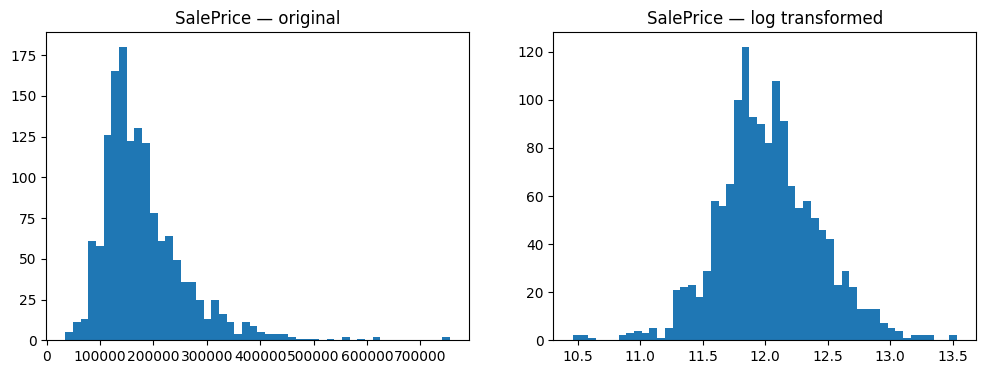

Linear Regression + Scaling + Log Target RMSE: 0.1343 (+/- 0.0181)


In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(y, bins=50)
ax1.set_title('SalePrice — original')
ax2.hist(np.log1p(y), bins=50)
ax2.set_title('SalePrice — log transformed')
plt.show()

y_log = np.log1p(y)
lr = LinearRegression()
mean, std = rmse_cv(lr, X_scaled, y_log)
print(f"Linear Regression + Scaling + Log Target RMSE: {mean:.4f} (+/- {std:.4f})")

In [30]:
with mlflow.start_run(run_name="linear_regression_scaled_log"):
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_param("features_count", X_scaled.shape[1])
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run linear_regression_scaled_log at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/5d2912228dc84376a0fed0c72a34a38c
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1343 (+/- 0.0181)


In [31]:
from sklearn.linear_model import Ridge

for alpha in [0.1, 1, 10, 50, 100, 200]:
    ridge = Ridge(alpha=alpha)
    mean, std = rmse_cv(ridge, X_scaled, y_log)
    print(f"Ridge alpha={alpha}: RMSE {mean:.4f} (+/- {std:.4f})")

Ridge alpha=0.1: RMSE 0.1343 (+/- 0.0182)
Ridge alpha=1: RMSE 0.1339 (+/- 0.0189)
Ridge alpha=10: RMSE 0.1340 (+/- 0.0215)
Ridge alpha=50: RMSE 0.1360 (+/- 0.0232)
Ridge alpha=100: RMSE 0.1366 (+/- 0.0234)
Ridge alpha=200: RMSE 0.1368 (+/- 0.0232)


In [32]:
with mlflow.start_run(run_name="ridge_alpha_0.1"):
    ridge = Ridge(alpha=0.1)
    mean, std = rmse_cv(ridge, X_scaled, y_log)
    
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 0.1)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run ridge_alpha_0.1 at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/9c6a74eb65604d62a3b5971086d87550
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1343 (+/- 0.0182)


### Lasso Regression
Lasso uses L1 regularization which can zero out weak features entirely, effectively doing feature selection automatically.

In [33]:
from sklearn.linear_model import Lasso

for alpha in [0.0001, 0.001, 0.01, 0.1]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    mean, std = rmse_cv(lasso, X_scaled, y_log)
    print(f"Lasso alpha={alpha}: RMSE {mean:.4f} (+/- {std:.4f})")

Lasso alpha=0.0001: RMSE 0.1335 (+/- 0.0187)
Lasso alpha=0.001: RMSE 0.1346 (+/- 0.0240)
Lasso alpha=0.01: RMSE 0.1440 (+/- 0.0240)
Lasso alpha=0.1: RMSE 0.2132 (+/- 0.0131)


In [34]:
with mlflow.start_run(run_name="lasso_alpha_0.0001"):
    lasso = Lasso(alpha=0.0001, max_iter=10000)
    mean, std = rmse_cv(lasso, X_scaled, y_log)
    
    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.0001)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run lasso_alpha_0.0001 at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/ea28a55086b7439f85f324960f4271d3
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1335 (+/- 0.0187)


In [35]:
from sklearn.linear_model import ElasticNet

for alpha in [0.0001, 0.001, 0.01]:
    for l1_ratio in [0.2, 0.5, 0.8]:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        mean, std = rmse_cv(en, X_scaled, y_log)
        print(f"ElasticNet alpha={alpha} l1_ratio={l1_ratio}: RMSE {mean:.4f} (+/- {std:.4f})")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.569e-01, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.421e-01, tolerance: 1.800e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.231e-01, tolerance: 1.837e

ElasticNet alpha=0.0001 l1_ratio=0.2: RMSE 0.1340 (+/- 0.0183)
ElasticNet alpha=0.0001 l1_ratio=0.5: RMSE 0.1338 (+/- 0.0184)
ElasticNet alpha=0.0001 l1_ratio=0.8: RMSE 0.1336 (+/- 0.0186)
ElasticNet alpha=0.001 l1_ratio=0.2: RMSE 0.1331 (+/- 0.0200)
ElasticNet alpha=0.001 l1_ratio=0.5: RMSE 0.1327 (+/- 0.0216)
ElasticNet alpha=0.001 l1_ratio=0.8: RMSE 0.1336 (+/- 0.0230)
ElasticNet alpha=0.01 l1_ratio=0.2: RMSE 0.1358 (+/- 0.0235)
ElasticNet alpha=0.01 l1_ratio=0.5: RMSE 0.1373 (+/- 0.0237)
ElasticNet alpha=0.01 l1_ratio=0.8: RMSE 0.1411 (+/- 0.0241)


In [36]:
from sklearn.linear_model import ElasticNet

for alpha in [0.00005, 0.0001, 0.0002, 0.0003]:
    for l1_ratio in [0.7, 0.8, 0.9, 0.95]:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        mean, std = rmse_cv(en, X_scaled, y_log)
        print(f"alpha={alpha} l1_ratio={l1_ratio}: RMSE {mean:.4f} (+/- {std:.4f})")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.098e-01, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.810e-01, tolerance: 1.837e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.918e-01, tolerance: 1.901e

alpha=5e-05 l1_ratio=0.7: RMSE 0.1339 (+/- 0.0183)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.152e-01, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.886e-01, tolerance: 1.837e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.999e-01, tolerance: 1.901e

alpha=5e-05 l1_ratio=0.8: RMSE 0.1339 (+/- 0.0184)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.259e-01, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.681e-02, tolerance: 1.901e-02
  model = cd_fast.enet_coordinate_descent(


alpha=5e-05 l1_ratio=0.9: RMSE 0.1338 (+/- 0.0184)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.391e-01, tolerance: 1.891e-02
  model = cd_fast.enet_coordinate_descent(


alpha=5e-05 l1_ratio=0.95: RMSE 0.1338 (+/- 0.0184)
alpha=0.0001 l1_ratio=0.7: RMSE 0.1337 (+/- 0.0186)
alpha=0.0001 l1_ratio=0.8: RMSE 0.1336 (+/- 0.0186)
alpha=0.0001 l1_ratio=0.9: RMSE 0.1336 (+/- 0.0187)
alpha=0.0001 l1_ratio=0.95: RMSE 0.1335 (+/- 0.0187)
alpha=0.0002 l1_ratio=0.7: RMSE 0.1333 (+/- 0.0191)
alpha=0.0002 l1_ratio=0.8: RMSE 0.1332 (+/- 0.0192)
alpha=0.0002 l1_ratio=0.9: RMSE 0.1332 (+/- 0.0194)
alpha=0.0002 l1_ratio=0.95: RMSE 0.1331 (+/- 0.0194)
alpha=0.0003 l1_ratio=0.7: RMSE 0.1330 (+/- 0.0196)
alpha=0.0003 l1_ratio=0.8: RMSE 0.1329 (+/- 0.0198)
alpha=0.0003 l1_ratio=0.9: RMSE 0.1328 (+/- 0.0200)
alpha=0.0003 l1_ratio=0.95: RMSE 0.1327 (+/- 0.0201)


In [37]:
with mlflow.start_run(run_name="elasticnet_alpha_0.0003_l1_0.95"):
    en = ElasticNet(alpha=0.0003, l1_ratio=0.95, max_iter=10000)
    mean, std = rmse_cv(en, X_scaled, y_log)
    
    mlflow.log_param("model", "ElasticNet")
    mlflow.log_param("alpha", 0.0003)
    mlflow.log_param("l1_ratio", 0.95)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run elasticnet_alpha_0.0003_l1_0.95 at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/5c5c1d329d60492cb80e6d1ba9c8c996
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1327 (+/- 0.0201)


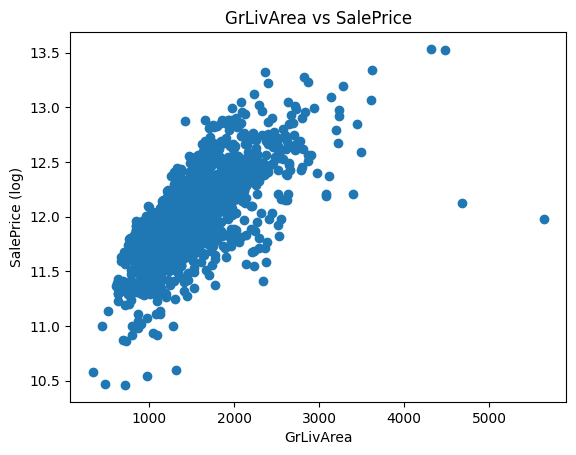

      GrLivArea
1298       5642
523        4676
1182       4476
691        4316
1169       3627


In [38]:
import matplotlib.pyplot as plt

# GrLivArea is known to have outliers in this dataset
plt.scatter(train['GrLivArea'], y_log)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice (log)')
plt.title('GrLivArea vs SalePrice')
plt.show()

# Show the suspicious ones
print(train[['GrLivArea']].nlargest(5, 'GrLivArea'))

In [39]:
# Remove the two clear outliers - large area but very low price
outlier_idx = train[(train['GrLivArea'] > 4000) & (y_log < 12.5)].index
print("Outliers to remove:", outlier_idx.tolist())

X_clean = X.drop(index=outlier_idx)
y_clean = y_log.drop(index=outlier_idx)

print(f"X shape before: {X.shape}, after: {X_clean.shape}")

# Retrain linear regression
lr = LinearRegression()
mean, std = rmse_cv(lr, X_scaled[X_clean.index], y_clean)
print(f"\nLinear Regression after outlier removal: {mean:.4f} (+/- {std:.4f})")

Outliers to remove: [523, 1298]
X shape before: (1460, 147), after: (1458, 147)

Linear Regression after outlier removal: 0.1173 (+/- 0.0074)


In [40]:
with mlflow.start_run(run_name="linear_regression_outliers_removed"):
    lr = LinearRegression()
    mean, std = rmse_cv(lr, X_scaled[X_clean.index], y_clean)
    
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

🏃 View run linear_regression_outliers_removed at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/f341678930654944b04255300ecf374a
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1173 (+/- 0.0074)


In [41]:
from sklearn.preprocessing import StandardScaler

# Rescale without outliers
scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

lasso = Lasso(alpha=0.0003, max_iter=10000)
mean, std = rmse_cv(lasso, X_clean_scaled, y_clean)
print(f"Lasso after outlier removal: {mean:.4f} (+/- {std:.4f})")

Lasso after outlier removal: 0.1146 (+/- 0.0059)


In [44]:
with mlflow.start_run(run_name="lasso_outliers_removed"):
    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.0003)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)
    mlflow.sklearn.log_model(lasso, artifact_path="lasso_model")

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

2026/04/11 18:15:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 18:16:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_outliers_removed at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/c00d937c03ac487d881326b7097c1407
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Logged — RMSE: 0.1146 (+/- 0.0059)


In [ ]:
en = ElasticNet(alpha=0.0003, l1_ratio=0.95, max_iter=10000)
mean, std = rmse_cv(en, X_clean_scaled, y_clean)
print(f"ElasticNet after outlier removal: {mean:.4f} (+/- {std:.4f})")

In [ ]:
with mlflow.start_run(run_name="elasticnet_outliers_removed"):
    mlflow.log_param("model", "ElasticNet")
    mlflow.log_param("alpha", 0.0003)
    mlflow.log_param("l1_ratio", 0.95)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

In [ ]:
ridge = Ridge(alpha=0.1)
mean, std = rmse_cv(ridge, X_clean_scaled, y_clean)
print(f"Ridge after outlier removal: {mean:.4f} (+/- {std:.4f})")

In [ ]:
with mlflow.start_run(run_name="ridge_outliers_removed"):
    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 0.1)
    mlflow.log_param("scaling", True)
    mlflow.log_param("log_target", True)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("rmse_cv_mean", mean)
    mlflow.log_metric("rmse_cv_std", std)

print(f"✅ Logged — RMSE: {mean:.4f} (+/- {std:.4f})")

## Decision Tree
Decision trees tend to overfit — they memorize training data. We'll show this by comparing train RMSE vs cross-validation RMSE.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_clean, y_clean)

train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)

print(f"Train RMSE:  {train_rmse:.4f}")
print(f"CV RMSE:     {cv_mean:.4f} (+/- {cv_std:.4f})")
print(f"Overfit gap: {cv_mean - train_rmse:.4f}")

In [ ]:
with mlflow.start_run(run_name="decision_tree_default_clean"):
    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("train_rmse", 0.0010)
    mlflow.log_metric("rmse_cv_mean", 0.1998)
    mlflow.log_metric("rmse_cv_std", 0.0122)
    mlflow.log_metric("overfit_gap", 0.1988)

print("✅ Logged")

In [ ]:
for depth in [3, 5, 7, 10, 15]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_clean, y_clean)
    train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
    cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)
    print(f"max_depth={depth}: Train {train_rmse:.4f} | CV {cv_mean:.4f} (+/- {cv_std:.4f})")

In [ ]:
with mlflow.start_run(run_name="decision_tree_max_depth_5_clean"):
    dt = DecisionTreeRegressor(max_depth=5, random_state=42)
    dt.fit(X_clean, y_clean)
    train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
    cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("rmse_cv_mean", cv_mean)
    mlflow.log_metric("rmse_cv_std", cv_std)
    mlflow.log_metric("overfit_gap", cv_mean - train_rmse)

print(f"✅ Logged — Train: {train_rmse:.4f} CV: {cv_mean:.4f}")

In [ ]:
for min_split in [5, 10, 20, 50]:
    for min_leaf in [3, 5, 10]:
        dt = DecisionTreeRegressor(max_depth=5, min_samples_split=min_split, 
                                   min_samples_leaf=min_leaf, random_state=42)
        dt.fit(X_clean, y_clean)
        train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
        cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)
        print(f"min_split={min_split} min_leaf={min_leaf}: Train {train_rmse:.4f} | CV {cv_mean:.4f} (+/- {cv_std:.4f})")

In [ ]:
with mlflow.start_run(run_name="decision_tree_tuned"):
    dt = DecisionTreeRegressor(max_depth=5, min_samples_split=5, 
                               min_samples_leaf=10, random_state=42)
    dt.fit(X_clean, y_clean)
    train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
    cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("min_samples_leaf", 10)
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("rmse_cv_mean", cv_mean)
    mlflow.log_metric("rmse_cv_std", cv_std)
    mlflow.log_metric("overfit_gap", cv_mean - train_rmse)

print(f"✅ Logged — Train: {train_rmse:.4f} CV: {cv_mean:.4f}")

In [ ]:
for max_feat in ['sqrt', 'log2', 0.5, 0.7, 1.0]:
    dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, 
                               max_features=max_feat, random_state=42)
    dt.fit(X_clean, y_clean)
    train_rmse = np.sqrt(mean_squared_error(y_clean, dt.predict(X_clean)))
    cv_mean, cv_std = rmse_cv(dt, X_clean, y_clean)
    print(f"max_features={max_feat}: Train {train_rmse:.4f} | CV {cv_mean:.4f} (+/- {cv_std:.4f})")

In [ ]:
print("y_clean sample:", y_clean[:5].values)
print("Is y_clean log transformed?", y_clean.max() < 20)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_clean, y_clean)

train_rmse = np.sqrt(mean_squared_error(y_clean, rf.predict(X_clean)))
cv_mean, cv_std = rmse_cv(rf, X_clean, y_clean)

print(f"Train RMSE:  {train_rmse:.4f}")
print(f"CV RMSE:     {cv_mean:.4f} (+/- {cv_std:.4f})")
print(f"Overfit gap: {cv_mean - train_rmse:.4f}")

In [ ]:
with mlflow.start_run(run_name="random_forest_default"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("outliers_removed", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("rmse_cv_mean", cv_mean)
    mlflow.log_metric("rmse_cv_std", cv_std)
    mlflow.log_metric("overfit_gap", cv_mean - train_rmse)

print(f"✅ Logged — Train: {train_rmse:.4f} CV: {cv_mean:.4f}")

In [ ]:
for n_est in [100, 200, 300]:
    for max_depth in [10, 15, 20, None]:
        rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_depth, 
                                   random_state=42, n_jobs=-1)
        rf.fit(X_clean, y_clean)
        train_rmse = np.sqrt(mean_squared_error(y_clean, rf.predict(X_clean)))
        cv_mean, cv_std = rmse_cv(rf, X_clean, y_clean)
        print(f"n_est={n_est} max_depth={max_depth}: Train {train_rmse:.4f} | CV {cv_mean:.4f} (+/- {cv_std:.4f})")

In [49]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Train best model on full clean data
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(X_clean)

lasso_final = Lasso(alpha=0.0003, max_iter=10000)
lasso_final.fit(X_final, y_clean)

# Log and register model
with mlflow.start_run(run_name="best_model_registration"):
    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.0003)
    mlflow.log_param("outliers_removed", 2)
    
    mlflow.sklearn.log_model(
        lasso_final, 
        artifact_path="model",
        registered_model_name="house_prices_best_model"
    )
    
print("✅ Model registered in MLflow Model Registry")

2026/04/11 19:07:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 19:07:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_prices_best_model' already exists. Creating a new version of this model...
2026/04/11 19:07:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_prices_best_model, version 2
Created version '2' of model 'house_prices_best_model'.


🏃 View run best_model_registration at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/25b0b78887e54828bab728fe717d2b27
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Model registered in MLflow Model Registry


In [52]:
from sklearn.linear_model import Lasso

lasso_final = Lasso(alpha=0.0003, max_iter=10000)
lasso_final.fit(X_clean_scaled, y_clean)

with mlflow.start_run(run_name="best_model_final"):
    mlflow.sklearn.log_model(
        lasso_final,
        artifact_path="model",
        registered_model_name="house_prices_best_model"
    )

print("✅ Model registered as version 4")

2026/04/11 19:39:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 19:39:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_prices_best_model' already exists. Creating a new version of this model...
2026/04/11 19:40:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_prices_best_model, version 4
Created version '4' of model 'house_prices_best_model'.


🏃 View run best_model_final at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0/runs/51cf7cf5273a406e86d601afc21c6d00
🧪 View experiment at: https://dagshub.com/GiorgiMzarelua/ml_assignment_1.mlflow/#/experiments/0
✅ Model registered as version 4
